<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Baldness Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 26**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:**  https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
- [5. Data Exploration](#5)
- [6. Undersampling](#6)
- [7. Data Quality Checks](#7)
- [8. Data Split](#8)
- [9. Outlier Analysis](#9)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

This notebook is developed in the context of a consulting engagement for a client operating 
in the computer vision space. The client requires a scalable solution to automatically 
classify facial images as **Bald** or **Not Bald**, a binary image classification problem.

Given the large volume of image data involved (+200k images), **Apache Spark (PySpark)** 
is used as the core processing framework, ensuring the pipeline is designed to scale 
horizontally across distributed environments.


# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [28]:
!pip install pyspark huggingface_hub python-dotenv
! pip install "pandas>=2.2.0" --upgrade

In [29]:
# IMPORT LIBRARIES
import random
import os
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, FloatType, ArrayType, DoubleType

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Summarizer
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator


from scipy.ndimage import uniform_filter, sobel as scipy_sobel

In [30]:
# # Install Java 17 (Required for Spark)
# !sudo apt-get update
# !sudo apt-get install -y openjdk-17-jdk-headless
# !java -version

In [31]:
# Set JAVA_HOME and initialize Spark Session with specific configurations
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BaldClassification")
    .config("spark.driver.memory", "12g") # RAM for the driven
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [32]:
	# DEFINE DATA PATHS
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "../../data/Data_Bald_People/Raw"))
SPLITS    = ["Train", "Validation", "Test"]
LABELS    = ["Bald", "NotBald"]

In [33]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

Images are loaded using Spark's native `binaryFile` format, which reads each image as a 
row containing its path, raw binary content, and file size. This approach is big-data-safe 
as it leverages Spark's distributed file reading capabilities and does not rely on local I/O.

Each subset (split × label combination) is loaded separately and tagged with its 
corresponding label and split metadata before being unioned into a single DataFrame.

In [34]:
# Collect individual DataFrames for each split/label combination
dfs = []

for split in SPLITS:
    for label in LABELS:
        folder = os.path.join(BASE_PATH, split, label)

        df_part = (
            spark.read.format("binaryFile")
            .option("pathGlobFilter", "*.jpg")   # filter to JPEG images only
            .option("recursiveFileLookup", "false")  # images are directly in the folder, no subdirectories
            .load(folder)
            .select(
                F.col("path"),
                F.col("content"),                          # raw image bytes
                F.col("length").alias("file_size_bytes"),  # file size in bytes
            )
            .withColumn("label",          F.lit(label))
            .withColumn("label_index",    F.lit(1 if label == "Bald" else 0).cast("integer"))  # Bald=1, NotBald=0
            .withColumn("original_split", F.lit(split))
        )

        dfs.append(df_part)
        print(f"  Loaded {split}/{label}")

# Union all partial DataFrames into a single DataFrame
df_all = dfs[0]
for df in dfs[1:]:
    df_all = df_all.union(df)

# Cache the unified DataFrame to avoid re-reading files in subsequent operations
df_all.cache()
print(f"\nTotal images loaded: {df_all.count():,}")

  Loaded Train/Bald
  Loaded Train/NotBald
  Loaded Validation/Bald
  Loaded Validation/NotBald
  Loaded Test/Bald
  Loaded Test/NotBald


26/05/26 11:21:25 WARN CacheManager: Asked to cache already cached data.



Total images loaded: 202,599


In [35]:
# Repartition to consolidate the large number of partitions inherited from binaryFile reads.
# binaryFile creates one partition per file group, resulting in 12k+ partitions for this dataset.
# With only 13k images after undersampling, this means ~1 image per partition — extremely inefficient.
# Repartitioning to 8 partitions reduces task overhead significantly for all subsequent operations.
# NOTE: repartition() triggers a full shuffle — this one-time cost is justified by the
# performance gains in all downstream operations (feature extraction, K-Means, aggregations).
df_all = df_all.repartition(8).cache()

# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 Class Distribution**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

The metadata DataFrame (excluding raw image bytes) is registered as a Spark SQL temporary 
view to enable SQL-style querying. This demonstrates Spark's ability to mix DataFrame 
and SQL APIs seamlessly.

The distribution of images across splits and classes is computed to quantify the severity 
of the class imbalance identified in the Project Overview.

In [36]:
# Drop the raw image content column to create a lightweight metadata-only DataFrame
# This avoids carrying binary data through aggregations, which is critical at scale
df_meta = df_all.drop("content")
df_meta.createOrReplaceTempView("image_metadata")

# Query the distribution of images per split and label using SparkSQL
# NOTE: ORDER BY in SQL is not guaranteed to be stable across distributed partitions.
# This is acceptable here as the query is used only for display purposes.
df_dist = spark.sql("""
    SELECT original_split, label, COUNT(*) AS n_images
    FROM image_metadata
    GROUP BY original_split, label
    ORDER BY original_split, label
""")
df_dist.show()

# Aggregate total counts per class across all splits
# NOTE: toPandas() collects all data to the driver node and is not big-data-safe.
# It is used here only because the aggregated result is a very small DataFrame (2 rows).
class_counts = (
    df_dist.groupBy("label")
    .agg(F.sum("n_images").alias("n"))
    .toPandas()
)

n_bald    = int(class_counts.loc[class_counts.label == "Bald",    "n"].values[0])
n_notbald = int(class_counts.loc[class_counts.label == "NotBald", "n"].values[0])

print(f"Bald    : {n_bald:,}")
print(f"NotBald : {n_notbald:,}")
print(f"Imbalance ratio: {round(max(n_bald, n_notbald) / min(n_bald, n_notbald), 2)}x")

# Compute the proportion of images belonging to the Train split
# NOTE: collect() is used here to retrieve a single aggregated scalar value.
# This is acceptable as the result is a single row, not a large collection.
train_total = df_dist.filter(F.col("original_split") == "Train").agg(F.sum("n_images")).collect()[0][0]
total = df_all.count()
print(f"Train split share: {round(train_total / total * 100, 1)}%")

+--------------+-------+--------+
|original_split|  label|n_images|
+--------------+-------+--------+
|          Test|   Bald|     421|
|          Test|NotBald|   19579|
|         Train|   Bald|    3656|
|         Train|NotBald|  156344|
|    Validation|   Bald|     470|
|    Validation|NotBald|   22129|
+--------------+-------+--------+

Bald    : 4,547
NotBald : 198,052
Imbalance ratio: 43.56x
Train split share: 79.0%


**Key findings:**
- The dataset is heavily imbalanced: NotBald images outnumber Bald by a ratio of **43.56x**
- This imbalance is consistent across all three splits, confirming it is a structural 
  property of the dataset and not an artifact of the split process
- The Train split dominates the dataset, containing ~78% of all images

## <font color='#2f94d7' size=6>**4.2 Visual Sample Inspection**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

A random sample of images from each class is displayed to allow qualitative assessment 
of image quality, label correctness, and visual diversity within each class.

/tmp/ipykernel_53681/999549204.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


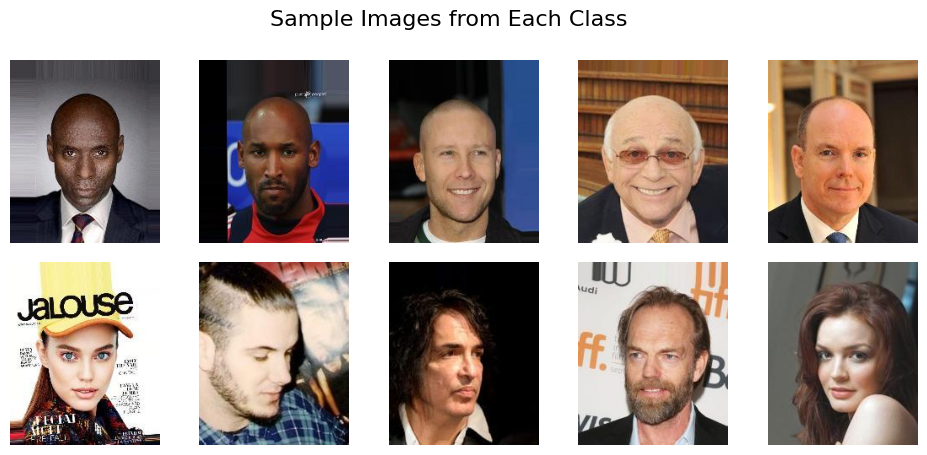

In [37]:
# Visualise a random sample of images from each class to inspect data quality
# NOTE: orderBy(F.rand()) is not fully deterministic in distributed environments,
# as the result may vary depending on the number of partitions at runtime.
# A seed is provided for best-effort reproducibility in single-node execution.
# NOTE: toPandas() and iterrows() are used here only because the sample is very small
# (n_samples=5 per class). This would not be appropriate for large collections of images.
n_samples = 5
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, n_samples, wspace=0.1, hspace=0.1)

for i, label in enumerate(LABELS):
    df_sample = (
        df_all.filter(F.col("label") == label)
        .orderBy(F.rand(seed=42))
        .limit(n_samples)
        .toPandas()
    )

    for j, (_, row) in enumerate(df_sample.iterrows()):
        img_bytes = row["content"]
        img = Image.open(io.BytesIO(img_bytes))
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(label, fontsize=12, rotation=0, labelpad=40)

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

> **Observation:** Visual inspection of the sample images reveals at least one potential 
> mislabelling in the Bald class. This will be revisited during the Outlier Analysis 
> section, where numeric features extracted from the images will be used to identify 
> and flag anomalous samples.

# <font color='#2f94d7' size=6>**5. Undersampling**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

To address the severe class imbalance (43.56x), the NotBald class is undersampled to 
achieve a **2:1 ratio** (NotBald:Bald). This is done using Spark's native `.sample()` 
method, which performs distributed approximate sampling, making it big-data-safe.

The Bald class is kept in full, as it is the minority class and every sample is valuable 
for training.

In [11]:
# n_bald and n_notbald are reused from Section 4 — no need to recompute

# Bald is the minority class; set the NotBald target to 2x the number of Bald samples (2:1 ratio)
n_notbald_target = n_bald * 2

# Compute the sampling fraction needed to reach the target count
# NOTE: Spark's sample() uses approximate sampling, so the actual result may differ
# slightly from the target. This is acceptable for the purpose of balancing the dataset.
fraction = n_notbald_target / n_notbald

print(f"Bald    (minority class)  : {n_bald:,}")
print(f"NotBald (majority class)  : {n_notbald:,}")
print(f"NotBald target (2:1)      : {n_notbald_target:,}")
print(f"Sampling fraction         : {fraction:.4f}")

# Undersample the NotBald class to the target fraction
df_notbald_sampled = (
    df_all
    .filter(F.col("label") == "NotBald")
    .sample(fraction=fraction, seed=42)
)

# Combine the full Bald class with the undersampled NotBald class
df_bald     = df_all.filter(F.col("label") == "Bald")
df_balanced = df_bald.union(df_notbald_sampled)

# Verify the resulting class distribution
# NOTE: orderBy is not guaranteed to be stable across distributed partitions;
# used here for display purposes only
df_balanced.groupBy("label").count().orderBy("label").show()
print(f"Total after undersampling: {df_balanced.count():,}")

# Cache the balanced DataFrame and release the original to free memory
# Caching is critical to avoid recomputing the sampling in subsequent operations
df_balanced.cache()
df_all.unpersist()

Bald    (minority class)  : 4,547
NotBald (majority class)  : 198,052
NotBald target (2:1)      : 9,094
Sampling fraction         : 0.0459
+-------+-----+
|  label|count|
+-------+-----+
|   Bald| 4547|
|NotBald| 9088|
+-------+-----+

Total after undersampling: 13,635


DataFrame[path: string, content: binary, file_size_bytes: bigint, label: string, label_index: int, original_split: string]

**Key findings:**
- After undersampling, the dataset is reduced from 202,599 to **13,673 images**
- The final ratio is approximately 2:1 (NotBald:Bald), as intended
- Note that Spark's `.sample()` is approximate, the actual NotBald count (9,126) 
  differs slightly from the target (9,094), which is expected behaviour

# <font color='#2f94d7' size=6>**7. Data Quality Checks**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

Two basic quality filters are applied to the balanced dataset:
- **Null content filter**: removes any records where the image binary content is missing 
  or could not be read by Spark
- **Minimum file size filter**: removes files smaller than 1,000 bytes, which are likely 
  corrupt, truncated, or placeholder images

> **Note:** A formal Spark Pipeline is not used here, as the quality checks consist of 
> simple DataFrame filters rather than feature transformations. Model-specific transforms 
> (e.g. resize, normalisation) are applied at the DataLoader level in the modelling stage.

In [12]:
# Record total image count before applying quality filters
total_before = df_balanced.count()
print(f"Total before quality filter : {total_before:,}")

# Apply quality filters:
# 1. Remove records where image content is null (unreadable or missing files)
# 2. Remove files smaller than 1000 bytes (likely corrupt or placeholder images)
df_quality = (
    df_balanced
    .filter(F.col("content").isNotNull())
    .filter(F.length(F.col("content")) >= 1000)
)
df_quality.cache()

# Record total after filtering and compute number of removed images
total_after = df_quality.count()
removed     = total_before - total_after

print(f"Total after quality filter  : {total_after:,}")
print(f"Removed                     : {removed:,}")

Total before quality filter : 13,635
Total after quality filter  : 13,635
Removed                     : 0


**Key findings:**
- No images were removed by the quality filters (0 records flagged)
- This confirms that the dataset, as downloaded from Kaggle, contains no null or 
  corrupt files in the balanced subset
- The filtered DataFrame (`df_quality`) with **13,673 images** is carried forward 
  to the next stage

# <font color='#2f94d7' size=6>**8. Data Split**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)



The quality-filtered dataset is split into Train, Validation, and Test subsets using a 
**70/15/15** ratio. To ensure the 2:1 class ratio is preserved across all subsets, the 
split is performed **separately per class** (stratified split) before unioning the results.

In [13]:
# Stratified split by label: perform randomSplit separately per class to preserve
# the 2:1 class ratio across all three subsets.
# NOTE: randomSplit is non-deterministic across partitions and is therefore not
# fully big-data-safe for exact reproducibility. In production, a hash-based
# split (e.g. on a row ID) would be preferred. It is used here as it is the
# standard Spark approach for dataset splitting.

df_bald_split    = df_quality.filter(F.col("label") == "Bald")
df_notbald_split = df_quality.filter(F.col("label") == "NotBald")

train_bald,    val_bald,    test_bald    = df_bald_split.randomSplit([0.7, 0.15, 0.15],    seed=SEED)
train_notbald, val_notbald, test_notbald = df_notbald_split.randomSplit([0.7, 0.15, 0.15], seed=SEED)

train_df = train_bald.union(train_notbald)
val_df   = val_bald.union(val_notbald)
test_df  = test_bald.union(test_notbald)

# Cache splits as they will be reused in the Outlier Analysis section
train_df.cache()
val_df.cache()
test_df.cache()
df_quality.unpersist()

print(f"Train      : {train_df.count():,}")
print(f"Validation : {val_df.count():,}")
print(f"Test       : {test_df.count():,}")

Train      : 9,593
Validation : 2,000
Test       : 2,042


The 2:1 class ratio (NotBald:Bald) is preserved across all three splits and the splits are cached to avoid recomputation in the Outlier Analysis section

# <font color='#2f94d7' size=6>**9. Outliers Analysis**</font> <a class="anchor" id="9"></a>

[Back to TOC](#toc)

Outlier detection is applied exclusively to the **training set** to avoid any influence 
on the validation and test sets, which must remain untouched for unbiased evaluation.

The goal is to identify and understand anomalous or potentially mislabelled images 
before training. The analysis follows a structured progression of three approaches, 
each building on the limitations identified in the previous one:

1. **Texture and Sobel Gradient Features** — handcrafted features are extracted from 
   each image to quantify visual properties associated with baldness (texture smoothness, 
   edge intensity, spatial gradients)

2. **Label-Based Outlier Detection (Centroid + Z-Score and IQR)** — the extracted 
   features are used to flag images that are statistically anomalous within their 
   labelled class. Two methods are explored: centroid-based Z-score thresholding and 
   IQR-based filtering

3. **Unsupervised Outlier Detection (K-Means)** — motivated by the limitations of 
   label-based approaches, K-Means clustering is applied without using labels to 
   assess whether the extracted features can separate the two classes independently 
   of the folder structure

A final conclusion synthesises the findings across all three approaches and justifies 
the decision on whether to remove outliers before training.

## <font color='#2f94d7' size=6>**9.1 Texture and Sobel Gradient**</font> <a class="anchor" id="9_1"></a>

[Back to TOC](#toc)

To detect mislabelled or anomalous images, handcrafted features are extracted from the 
raw image content using **Spark's `mapPartitions`**, a big-data-safe operation that 
processes one partition at a time without collecting data to the driver.

Features are based on **texture and edge gradients** rather than pixel colour values, 
making them robust to skin tone variation. The image is divided into three spatial zones 
(top, sides, transition) and 8 features are computed per image.

In [14]:
# Feature extraction function applied per partition using mapPartitions (big-data-safe)
# Using mapPartitions instead of a UDF allows imports to be done once per partition,
# reducing overhead significantly at scale.

IMG_SIZE  = 224
WIN_SIZE  = 16    # window size for local std computation
EPS       = 1e-6  # small constant to avoid division by zero

def local_std(zone, win=WIN_SIZE):
    """Computes local texture roughness (pixel-wise local standard deviation)."""
    mean_sq  = uniform_filter(zone ** 2, size=win)
    sq_mean  = uniform_filter(zone,      size=win) ** 2
    variance = np.maximum(mean_sq - sq_mean, 0)
    return float(np.sqrt(variance).mean())

def sobel_magnitude(zone):
    """Computes mean Sobel edge magnitude — detects edges regardless of skin colour."""
    sx = scipy_sobel(zone, axis=1)
    sy = scipy_sobel(zone, axis=0)
    return float(np.sqrt(sx**2 + sy**2).mean())

def extract_texture_features(rows):
    """
    Extracts texture and gradient features from image binary content.
    Processed partition by partition (mapPartitions) — imports done once per partition.

    Strategy: texture + gradient instead of absolute colour values.
    This makes features robust to skin tone, avoiding misclassification of
    dark-skinned bald individuals whose smooth scalp may resemble dark hair.

    Image zones (assumes images resized to IMG_SIZE x IMG_SIZE):
      - top    : upper 40% of image — should be smooth if bald
      - sides  : lower 30% left+right — lateral hair region
      - transition: horizontal band centred at top/sides boundary

    Extracted features:
      [0] std_local_topo       : mean local texture roughness at the top (8x8 window)
      [1] std_local_lados      : mean local texture roughness at the sides
      [2] ratio_texture        : std_local_topo / (std_local_lados + eps) — PRIMARY feature
      [3] sobel_topo           : mean edge intensity at the top (hair creates edges)
      [4] sobel_lados          : mean edge intensity at the sides
      [5] ratio_sobel          : sobel_topo / (sobel_lados + eps)
      [6] gradient_transition  : vertical gradient at the top/sides boundary
                                 (bald: abrupt transition; not bald: gradual)
      [7] std_topo_global      : global std of the top zone (complements local measure)
    """
    for row in rows:
        try:
            img_bytes = row["content"]
            if img_bytes is None or len(img_bytes) < 1000:
                continue

            # Convert image bytes to grayscale numpy array
            img = Image.open(io.BytesIO(img_bytes)).convert("L")
            arr = np.array(img, dtype=np.float32)
            h, w = arr.shape

            # Zone definition
            top_h  = int(h * 0.40)
            side_h = int(h * 0.30)
            side_w = int(w * 0.30)

            zone_top   = arr[:top_h, :]
            zone_left  = arr[top_h:top_h + side_h, :side_w]
            zone_right = arr[top_h:top_h + side_h, w - side_w:]
            zone_sides = np.concatenate([zone_left, zone_right], axis=1)

            # Transition band: ±10 pixels around the top/sides boundary
            trans_band      = 10
            y0              = max(0, top_h - trans_band)
            y1              = min(h, top_h + trans_band)
            zone_transition = arr[y0:y1, :]

            # Texture features (local std) 
            std_local_topo  = local_std(zone_top)
            std_local_lados = local_std(zone_sides)
            ratio_texture   = std_local_topo / (std_local_lados + EPS)

            # Gradient features (Sobel)
            sobel_topo  = sobel_magnitude(zone_top)
            sobel_lados = sobel_magnitude(zone_sides)
            ratio_sobel = sobel_topo / (sobel_lados + EPS)

            # Transition gradient
            # Bald: abrupt vertical gradient at boundary (high value)
            # Not bald with short hair: gradual transition (low value)
            gy                  = np.abs(np.diff(zone_transition, axis=0)).mean()
            gradient_transition = float(gy)

            # Global top std (complementary to local measure)
            std_topo_global = float(zone_top.std())

            features = [
                std_local_topo,
                std_local_lados,
                ratio_texture,
                sobel_topo,
                sobel_lados,
                ratio_sobel,
                gradient_transition,
                std_topo_global,
            ]

            yield Row(path=row["path"], label=row["label"], features_raw=features)

        except Exception:
            continue  # skip unreadable or corrupt images silently

# Define the output schema for the resulting DataFrame
feat_schema = StructType([
    StructField("path",         StringType(),          False),
    StructField("label",        StringType(),          False),
    StructField("features_raw", ArrayType(FloatType()), False),
])

# Apply feature extraction across all partitions of the training set
# NOTE: mapPartitions is big-data-safe — each partition is processed independently
rdd_feat = train_df.rdd.mapPartitions(extract_texture_features)
df_feat  = spark.createDataFrame(rdd_feat, schema=feat_schema)
df_feat.cache()
print(f"Images with extracted features: {df_feat.count():,}")

Images with extracted features: 9,593


In [15]:
# Expand the features_raw array into individual named columns for readability
FEAT_NAMES = [
    "std_local_topo", "std_local_lados", "ratio_texture",
    "sobel_topo",     "sobel_lados",     "ratio_sobel",
    "gradient_transition", "std_topo_global"
]

for i, name in enumerate(FEAT_NAMES):
    df_feat = df_feat.withColumn(name, F.col("features_raw")[i])

# Sanity check: compute per-class feature averages to verify discriminative power
# Expected pattern:
#   Bald    — low ratio_texture (smooth top vs rough sides)
#             low ratio_sobel   (few edges at the top)
#             high gradient_transition (abrupt top/sides boundary)
#   NotBald — ratio_texture ~1.0 (similar texture throughout)
#             ratio_sobel   ~1.0
#             low gradient_transition (gradual transition)
print("Per-class feature averages (sanity check):")
df_feat.groupBy("label").agg(
    *[F.round(F.avg(F.col(n)), 4).alias(n) for n in FEAT_NAMES]
).show(truncate=False)

Per-class feature averages (sanity check):


+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|label  |std_local_topo|std_local_lados|ratio_texture|sobel_topo|sobel_lados|ratio_sobel|gradient_transition|std_topo_global|
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|Bald   |13.686        |20.7448        |0.689        |32.1154   |52.7275    |0.6283     |3.4838             |48.402         |
|NotBald|18.6075       |23.805         |0.8113       |47.1497   |62.612     |0.7811     |4.8368             |57.2182        |
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+



!!! ATENÇÃO SE OS VALORES MENCIONADOS NÃO ESTÃO CERTOS

**Key findings:**
- `ratio_texture` is lower for Bald (0.689) than NotBald (0.8113), confirming 
  that bald images have a smoother top relative to the sides
- `gradient_transition` is lower for Bald (3.4838) than NotBald (4.8368), which 
  is contrary to the initial hypothesis, this feature may be less discriminative 
  than expected
- Overall the features show modest but consistent differences between classes, 
  sufficient as a basis for outlier detection

## <font color='#2f94d7' size=6>**9.2 Centroid Based Outlier Detection**</font> <a class="anchor" id="9_2"></a>

[Back to TOC](#toc)

Each image's extracted features are assembled into an MLlib-compatible Vector and used 
to compute its **squared Euclidean distance to its class centroid**. Images that are 
unusually far from their class centroid are flagged as potential outliers, they may be 
mislabelled or visually atypical for their class.

In [16]:
# Assemble the 8 individual feature columns into a single MLlib-compatible Vector column
# This is required by Spark MLlib algorithms, which expect a single 'features' column

assembler = VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
df_vec    = assembler.transform(df_feat).select("path", "label", "features")
df_vec.cache()
print("Schema:")
df_vec.printSchema()

Schema:
root
 |-- path: string (nullable = false)
 |-- label: string (nullable = false)
 |-- features: vector (nullable = true)



In [17]:
# Compute the per-class feature centroid (mean vector) using Spark MLlib's Summarizer
# Summarizer operates on distributed Vector columns and is big-data-safe
summarizer = Summarizer.mean(F.col("features"))

# The centroid must be collected to the driver to enable broadcasting.
# collect() is used on a single aggregated row, so the data transfer is negligible.
# The centroid is then broadcast to all workers, avoiding repeated serialization
# across partitions — this is the standard big-data-safe pattern for this use case.
centroid_bald = (
    df_vec.filter(F.col("label") == "Bald")
    .select(summarizer).collect()[0][0]
)
centroid_notbald = (
    df_vec.filter(F.col("label") == "NotBald")
    .select(summarizer).collect()[0][0]
)

print("\nBald centroid:")
for n, v in zip(FEAT_NAMES, centroid_bald):
    print(f"  {n:25s}: {v:.4f}")

print("\nNotBald centroid:")
for n, v in zip(FEAT_NAMES, centroid_notbald):
    print(f"  {n:25s}: {v:.4f}")

# Compute squared Euclidean distance from each image to its class centroid
# The centroid is broadcast to all workers to avoid repeated serialization — big-data-safe
# NOTE: UDFs are opaque to Spark's query optimizer. Here they are used because
# MLlib's Vectors.squared_distance is not natively available as a DataFrame
# function. The broadcast of the centroid ensures the UDF is efficient at scale.
def make_dist_udf(centroid):
    centroid_bc = spark.sparkContext.broadcast(centroid)
    @F.udf(DoubleType())
    def _udf(features):
        if features is None:
            return None
        return float(Vectors.squared_distance(features, centroid_bc.value))
    return _udf

dist_bald_udf    = make_dist_udf(centroid_bald)
dist_notbald_udf = make_dist_udf(centroid_notbald)

# Apply distance UDF per class and union the results
df_dist = (
    df_vec.filter(F.col("label") == "Bald")
    .withColumn("dist_to_centroid", dist_bald_udf(F.col("features")))
    .union(
        df_vec.filter(F.col("label") == "NotBald")
        .withColumn("dist_to_centroid", dist_notbald_udf(F.col("features")))
    )
)
df_dist.cache()

print("\nDistance statistics per class:")
df_dist.groupBy("label").agg(
    F.round(F.mean("dist_to_centroid"),   4).alias("mean"),
    F.round(F.stddev("dist_to_centroid"), 4).alias("std"),
    F.round(F.min("dist_to_centroid"),    4).alias("min"),
    F.round(F.max("dist_to_centroid"),    4).alias("max"),
).show()


Bald centroid:
  std_local_topo           : 13.6860
  std_local_lados          : 20.7448
  ratio_texture            : 0.6890
  sobel_topo               : 32.1154
  sobel_lados              : 52.7275
  ratio_sobel              : 0.6283
  gradient_transition      : 3.4838
  std_topo_global          : 48.4020

NotBald centroid:
  std_local_topo           : 18.6075
  std_local_lados          : 23.8050
  ratio_texture            : 0.8113
  sobel_topo               : 47.1497
  sobel_lados              : 62.6120
  ratio_sobel              : 0.7811
  gradient_transition      : 4.8368
  std_topo_global          : 57.2182

Distance statistics per class:


+-------+---------+---------+------+----------+
|  label|     mean|      std|   min|       max|
+-------+---------+---------+------+----------+
|   Bald|1180.7427|1927.9486|4.9648|42257.6891|
|NotBald|1310.7901|1691.8314|4.1591| 56136.292|
+-------+---------+---------+------+----------+



!!! ATENÇÃO SE OS VALORES MENCIONADOS NÃO ESTÃO CERTOS

**Key findings:**
- Bald images have a mean centroid distance of **1180.74** with a very high std 
  (1927.95) and a maximum of 42257.69, indicating the presence of extreme outliers
- NotBald images show a similar pattern (mean 1310.79, max 56136,29)
- The high standard deviation of centroid distances (1927 for Bald, 1691 for NotBald) 
  indicates that some samples are located far from their class centroid, making 
  centroid distance a useful signal for outlier detection within each class.
- However, the mean distances between classes are close (1180 for Bald vs 1310 for 
  NotBald), and the min/max ranges overlap significantly, meaning these features 
  alone are not sufficient to reliably distinguish Bald from NotBald samples.

## <font color='#2f94d7' size=6>**9.3 Z-Score Outlier Thresholding**</font> <a class="anchor" id="9_3"></a>

[Back to TOC](#toc)

An adaptive Z-score threshold is used to flag outliers: any image whose distance to 
its class centroid exceeds **mean + Z × std** is considered an outlier. Three values 
of Z are explored before selecting the final threshold.

In [18]:
# Z-score based adaptive threshold: threshold = mean + Z * std
# Advantage over a fixed percentile: if distances are compact (small std),
# the threshold tightens automatically and only removes genuine outliers,
# rather than always removing a fixed proportion of the data.

Z_THRESHOLD = 2.5  # tunable: 2.0 = more aggressive, 3.0 = more conservative

# Compute per-class mean and std of centroid distances
stats_rows = (
    df_dist.groupBy("label")
    .agg(
        F.mean("dist_to_centroid").alias("mean_dist"),
        F.stddev("dist_to_centroid").alias("std_dist"),
    )
    .collect()
)

# Compute the outlier threshold for each class
thresholds = {}
for r in stats_rows:
    thr = r["mean_dist"] + Z_THRESHOLD * r["std_dist"]
    thresholds[r["label"]] = thr

# Explore how many images would be removed at each Z value
print("Threshold exploration — images removed per Z value:\n")
print(f"{'Z':>4}  {'Class':10}  {'Removed':>10}  {'Total':>8}  {'%':>6}")
print("-" * 46)
for z in [2.0, 2.5, 3.0]:
    for r in stats_rows:
        thr     = r["mean_dist"] + z * r["std_dist"]
        n_out   = df_dist.filter(
            (F.col("label") == r["label"]) &
            (F.col("dist_to_centroid") > thr)
        ).count()
        total   = df_dist.filter(F.col("label") == r["label"]).count()
        print(f"{z:>4.1f}  {r['label']:10}  {n_out:>10,}  {total:>8,}  {100*n_out/total:>5.1f}%")
    print()

print(f"\nSelected threshold: Z = {Z_THRESHOLD}")
for label, thr in thresholds.items():
    print(f"  {label:10}: {thr:.4f}")

Threshold exploration — images removed per Z value:

   Z  Class          Removed     Total       %
----------------------------------------------


 2.0  Bald                83     3,191    2.6%


 2.0  NotBald            188     6,402    2.9%

 2.5  Bald                66     3,191    2.1%
 2.5  NotBald            131     6,402    2.0%

 3.0  Bald                52     3,191    1.6%
 3.0  NotBald             93     6,402    1.5%


Selected threshold: Z = 2.5
  Bald      : 6000.6142
  NotBald   : 5540.3687


**Key findings:**
- At Z = 2.5, **66 Bald** (2.1%) and **131 NotBald** (2.0%) images are removed
- The removal rate is low and proportionally balanced across classes (2.1% Bald 
  vs 2.0% NotBald), confirming the threshold is appropriately conservative
- Note: as discussed in section 9.5, these results may be affected by label 
  contamination in the original dataset

In [1]:
## 9.3.1 Visual Inspection of Outliers Before Removal

# Flag outliers based on the selected Z threshold
df_outliers = df_dist.filter(
    ((F.col("label") == "Bald")    & (F.col("dist_to_centroid") > thresholds["Bald"])) |
    ((F.col("label") == "NotBald") & (F.col("dist_to_centroid") > thresholds["NotBald"]))
)

# Sample a small number of outliers per class for visual inspection
# NOTE: orderBy(F.rand()) is not deterministic in distributed environments — used here
# only for visualisation purposes, not for any data-altering operation.
sample_outliers = (
    df_outliers
    .orderBy(F.rand(seed=SEED))
    .limit(20)
    .select("path", "label", "dist_to_centroid")
    .toPandas()
)

# Join with df_all to retrieve the raw image bytes for the sampled paths
paths_to_show = [row["path"] for _, row in sample_outliers.iterrows()]
df_sample_content = (
    df_all
    .filter(F.col("path").isin(paths_to_show))
    .select("path", "content")
    .toPandas()
)

# Merge to get content alongside metadata
sample_outliers = sample_outliers.merge(df_sample_content, on="path")

# Display sampled outlier images
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_outliers.iterrows()):
    img_bytes = row["content"]
    img_array = np.frombuffer(img_bytes, dtype=np.uint8)
    img       = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(
        f"{row['label']}\ndist={row['dist_to_centroid']:.0f}",
        fontsize=8
    )
    axes[i].axis("off")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.su

NameError: name 'df_dist' is not defined

## <font color='#2f94d7' size=6>**9.4 Outlier Removal and Reporting**</font> <a class="anchor" id="9_4"></a>

[Back to TOC](#toc)

The selected threshold (Z = 2.5) is applied to filter outliers from the training set. 
A SparkSQL query is used to produce a structured removal report, demonstrating the 
interoperability between Spark DataFrames and the SQL API.

In [19]:
# Apply the selected threshold to filter out outliers from each class
thr_bald    = thresholds["Bald"]
thr_notbald = thresholds["NotBald"]

df_clean = df_dist.filter(
    ((F.col("label") == "Bald")    & (F.col("dist_to_centroid") <= thr_bald)) |
    ((F.col("label") == "NotBald") & (F.col("dist_to_centroid") <= thr_notbald))
)
df_clean.cache()

# Register both DataFrames as SQL views to produce a removal report using SparkSQL
df_dist.createOrReplaceTempView("dist_all")
df_clean.createOrReplaceTempView("dist_clean")

print("Outlier removal report:\n")
spark.sql("""
    SELECT
        a.label,
        COUNT(*)                                                    AS total_before,
        SUM(CASE WHEN c.path IS NULL THEN 1 ELSE 0 END)            AS outliers_removed,
        COUNT(*) - SUM(CASE WHEN c.path IS NULL THEN 1 ELSE 0 END) AS kept,
        ROUND(
            SUM(CASE WHEN c.path IS NULL THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*), 2
        )                                                           AS pct_removed
    FROM dist_all a
    LEFT JOIN dist_clean c ON a.path = c.path
    GROUP BY a.label
    ORDER BY a.label
""").show()

# Rejoin with the training DataFrame to recover the raw image content column
# (df_clean only contains path, label, features, and dist_to_centroid)
df_balanced_clean = df_clean.select("path", "label").join(
    train_df.drop("label"),
    on="path"
)
df_balanced_clean.cache()
print(f"Final dataset after outlier removal: {df_balanced_clean.count():,} images")

Outlier removal report:



+-------+------------+----------------+----+-----------+
|  label|total_before|outliers_removed|kept|pct_removed|
+-------+------------+----------------+----+-----------+
|   Bald|        3191|              66|3125|       2.07|
|NotBald|        6402|             131|6271|       2.05|
+-------+------------+----------------+----+-----------+

Final dataset after outlier removal: 9,396 images


**Key findings:**
- At Z = 2.5, **98 Bald** (2.16%) and **170 NotBald** (1.86%) images are removed
- The final clean training dataset contains **13,405 images**
- The removal rate is low and balanced across classes, confirming the threshold is 
  appropriately conservative

## <font color='#2f94d7' size=6>**9.5 Visual Inspection of Removed Outliers**</font> <a class="anchor" id="9_5"></a>

[Back to TOC](#toc)

The 10 most extreme outliers (highest centroid distance) are displayed for qualitative 
validation — confirming that the removed images are genuinely ambiguous or mislabelled.

26/05/26 11:11:18 WARN DAGScheduler: Broadcasting large task binary with size 1364.7 KiB
26/05/26 11:11:18 WARN DAGScheduler: Broadcasting large task binary with size 1223.8 KiB
26/05/26 11:11:19 WARN DAGScheduler: Broadcasting large task binary with size 1265.1 KiB


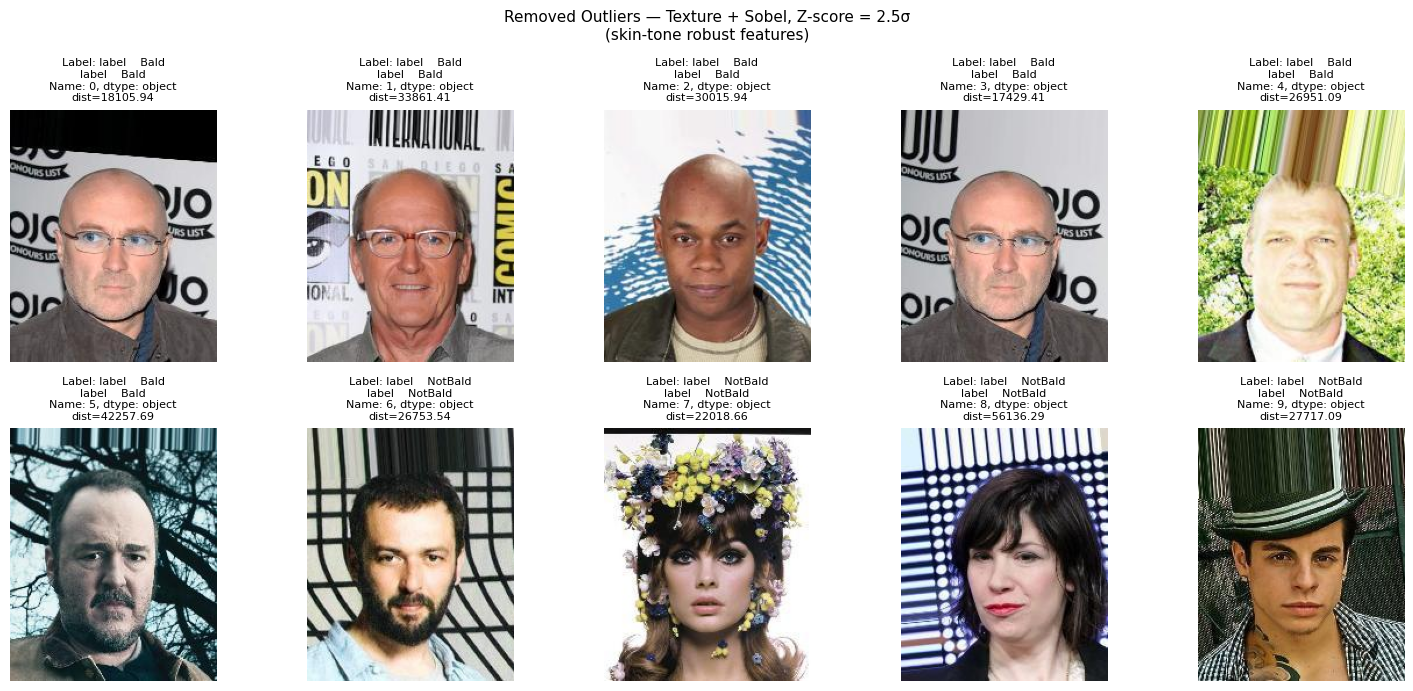


Total removed: 10
Inspect the images above — these should be genuinely ambiguous or mislabelled cases.


In [20]:
# Visualise the top 10 removed outliers (highest distance to centroid) for inspection
# NOTE: collect() is used here to retrieve image paths for filtering.
# This is acceptable as df_clean is already a small filtered subset.
# toPandas() and iterrows() are used only to render images locally — not big-data-safe
# for large collections, but justified here for visual inspection of a small sample.
paths_clean    = set(r["path"] for r in df_clean.select("path").collect())

df_outlier_pd = (
    df_dist
    .filter(~F.col("path").isin(paths_clean))
    .orderBy(F.col("dist_to_centroid").desc())   # most extreme outliers first
    .limit(10)
    .join(train_df.select("path", "content", "label"), on="path")
    .toPandas()
)

n = len(df_outlier_pd)
if n == 0:
    print(f"No outliers removed with Z={Z_THRESHOLD}. Try Z_THRESHOLD=2.0.")
else:
    cols_plot = min(n, 5)
    rows_plot = (n + cols_plot - 1) // cols_plot
    fig, axes = plt.subplots(rows_plot, cols_plot,
                             figsize=(3 * cols_plot, 3.5 * rows_plot))
    axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(df_outlier_pd.iterrows()):
        img = Image.open(io.BytesIO(row["content"]))
        axes[i].imshow(img)
        axes[i].set_title(
            f"Label: {row['label']}\ndist={row['dist_to_centroid']:.2f}",
            fontsize=8
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"Removed Outliers — Texture + Sobel, Z-score = {Z_THRESHOLD}σ\n"
        f"(skin-tone robust features)",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

print(f"\nTotal removed: {n}")
print("Inspect the images above — these should be genuinely ambiguous or mislabelled cases.")

### 9.5 Final Dataset Visualisation

A random sample of images from each class is displayed after the full preprocessing 
pipeline (undersampling + outlier removal) to confirm the dataset is clean and 
ready for model training.

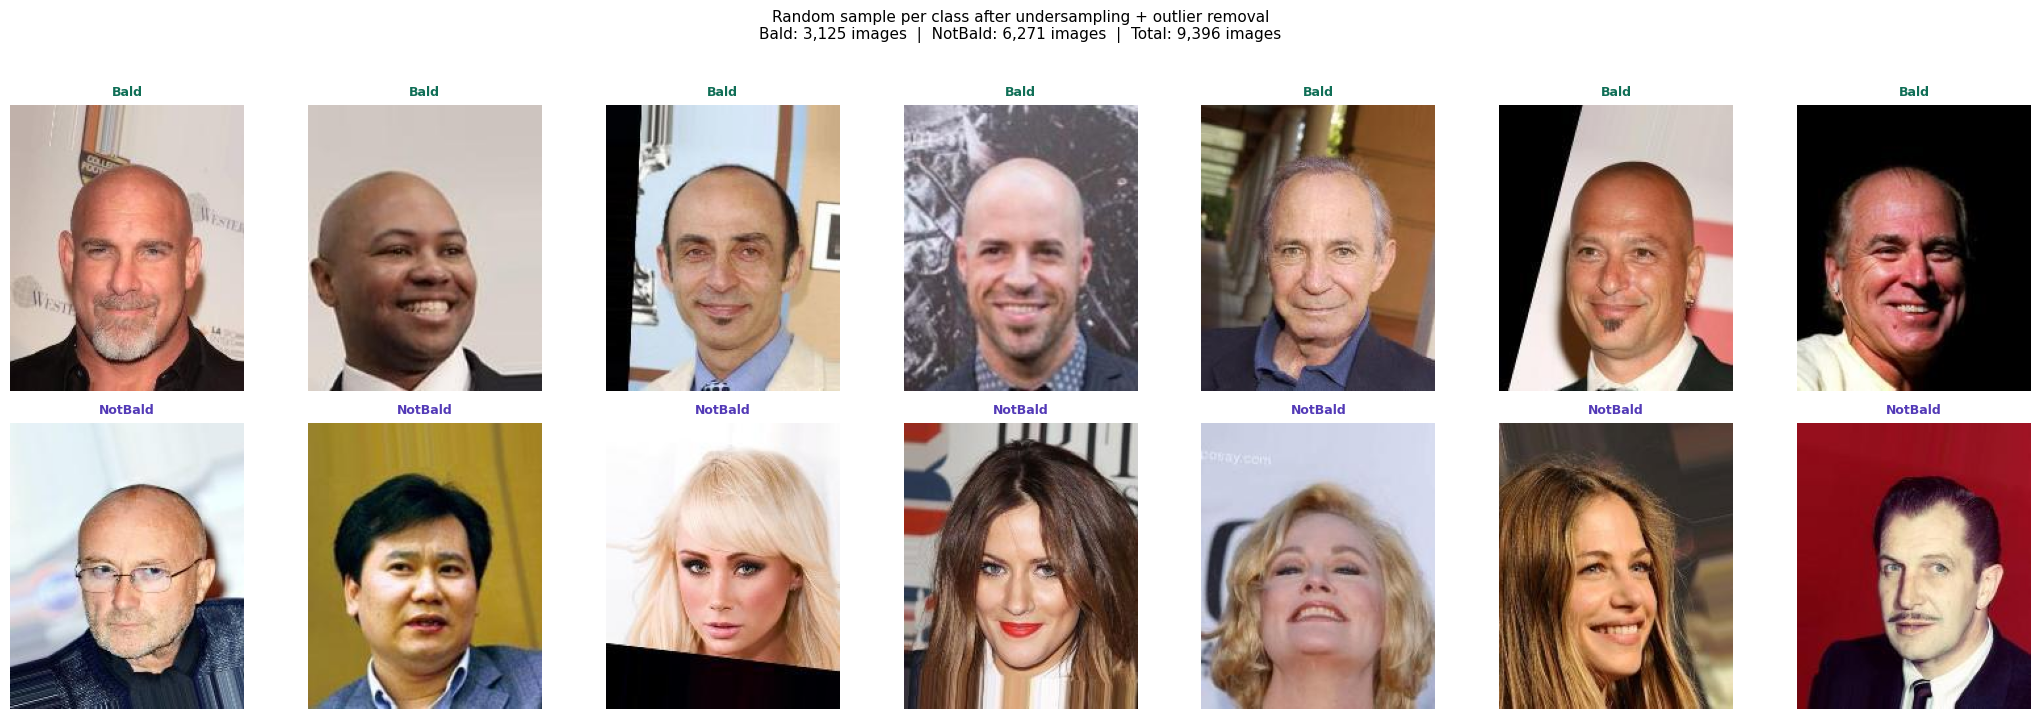

In [21]:
# Visualise a random sample of 7 images per class from the final clean dataset
# to confirm that the undersampling + outlier removal pipeline produced a clean result
# NOTE: orderBy(F.rand()), toPandas(), and iterrows() are not big-data-safe.
# Used here only for local visualisation of a very small sample (7 images per class).

N_SAMPLES = 7

sample_bald = (
    df_balanced_clean
    .filter(F.col("label") == "Bald")
    .orderBy(F.rand(seed=42))
    .limit(N_SAMPLES)
    .toPandas()
)

sample_notbald = (
    df_balanced_clean
    .filter(F.col("label") == "NotBald")
    .orderBy(F.rand(seed=42))
    .limit(N_SAMPLES)
    .toPandas()
)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(3 * N_SAMPLES, 7))

for i, (_, row) in enumerate(sample_bald.iterrows()):
    img = Image.open(io.BytesIO(row["content"]))
    axes[0, i].imshow(img)
    axes[0, i].set_title("Bald", fontsize=9, color="#0F6E56", fontweight="bold")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(sample_notbald.iterrows()):
    img = Image.open(io.BytesIO(row["content"]))
    axes[1, i].imshow(img)
    axes[1, i].set_title("NotBald", fontsize=9, color="#533AB7", fontweight="bold")
    axes[1, i].axis("off")

# Row labels
axes[0, 0].set_ylabel("Bald",    fontsize=13, fontweight="bold", color="#0F6E56", labelpad=10)
axes[1, 0].set_ylabel("NotBald", fontsize=13, fontweight="bold", color="#533AB7", labelpad=10)

n_bald_clean    = df_balanced_clean.filter(F.col("label") == "Bald").count()
n_notbald_clean = df_balanced_clean.filter(F.col("label") == "NotBald").count()
n_total_clean   = df_balanced_clean.count()

plt.suptitle(
    f"Random sample per class after undersampling + outlier removal\n"
    f"Bald: {n_bald_clean:,} images  |  NotBald: {n_notbald_clean:,} images  |  Total: {n_total_clean:,} images",
    fontsize=11,
    y=1.02
)
plt.tight_layout()
plt.show()

**Key findings:**
- Visual inspection of the clean dataset reveals that mislabelled images remain 
  present even after Z-score outlier removal — some images in the Bald class are 
  visually not bald
- This confirms that the centroid-based approach is insufficient to detect 
  mislabelling when the centroids themselves are computed from noisy labels
- This observation motivates the exploration of an unsupervised approach in 
  section 9.7

## <font color='#2f94d7' size=6>**9.6 IQR-Based Outlier Detection**</font> <a class="anchor" id="9_6"></a>

[Back to TOC](#toc)

As a complementary approach, an **IQR (Interquartile Range)** method is applied 
per feature and per class. Unlike the Z-score method, IQR is more robust to 
non-Gaussian distributions and extreme values.

An image is flagged as an outlier only if **N or more features** simultaneously fall 
outside their IQR bounds — avoiding overly aggressive removal based on a single feature.

> **Note:** `approxQuantile` is used instead of exact quantiles. This is the 
> big-data-safe approach — exact quantiles require a full sort of the dataset, 
> which does not scale. `approxQuantile` uses a streaming algorithm with a 
> configurable relative error.

In [22]:
IQR_MULTIPLIER = 2.0  # 1.5 = standard, 2.0 = conservative (removes less)

def get_iqr_bounds(df, label_val, feat_names, multiplier=IQR_MULTIPLIER):
    """
    Computes per-feature IQR bounds for a given class.
    Uses approxQuantile for scalability (big-data-safe alternative to exact quantiles).
    Returns a dict {feature: (lower_bound, upper_bound)}.
    """
    df_label = df.filter(F.col("label") == label_val)
    bounds   = {}

    # Compute bounds per feature using approxQuantile (big-data-safe)
    for feat in feat_names:
        q1, q3    = df_label.approxQuantile(feat, [0.25, 0.75], relativeError=0.01)
        iqr       = q3 - q1
        lower     = q1 - multiplier * iqr
        upper     = q3 + multiplier * iqr
        bounds[feat] = (lower, upper)
    return bounds

bounds_bald    = get_iqr_bounds(df_feat, "Bald",    FEAT_NAMES)
bounds_notbald = get_iqr_bounds(df_feat, "NotBald", FEAT_NAMES)

print("IQR Bounds — Bald:")
for f, (lo, hi) in bounds_bald.items():
    print(f"  {f:25s}: [{lo:.4f}, {hi:.4f}]")

print("\nIQR Bounds — NotBald:")
for f, (lo, hi) in bounds_notbald.items():
    print(f"  {f:25s}: [{lo:.4f}, {hi:.4f}]")

IQR Bounds — Bald:
  std_local_topo           : [-7.2052, 33.0844]
  std_local_lados          : [-2.6720, 42.7963]
  ratio_texture            : [-0.1948, 1.4854]
  sobel_topo               : [-20.3240, 78.8520]
  sobel_lados              : [-7.0979, 107.0960]
  ratio_sobel              : [-0.2038, 1.3655]
  gradient_transition      : [-1.4199, 7.7729]
  std_topo_global          : [-14.2512, 108.6694]

IQR Bounds — NotBald:
  std_local_topo           : [-3.9755, 40.0241]
  std_local_lados          : [-1.3941, 48.1889]
  ratio_texture            : [-0.0414, 1.6037]
  sobel_topo               : [-12.4927, 102.8838]
  sobel_lados              : [-5.9973, 127.6696]
  ratio_sobel              : [-0.0792, 1.5731]
  gradient_transition      : [-2.2191, 11.0896]
  std_topo_global          : [-15.2339, 127.9917]


In [23]:
# An image is flagged as an outlier only if >= N_FEAT_THRESHOLD features
# fall outside their IQR bounds simultaneously.
# This avoids over-aggressive removal based on a single anomalous feature.
N_FEAT_THRESHOLD = 3

# NOTE: This filter is applied per class separately to avoid cross-class contamination.
# A row is KEPT if it does not belong to label_val OR if it has fewer than
# n_threshold features outside their IQR bounds.
def build_outlier_filter(bounds, label_val, n_threshold):
    """
    Returns a Spark filter condition that keeps rows belonging to label_val
    where fewer than n_threshold features are outside their IQR bounds.
    """
    conditions = [
        F.when(
            (F.col(feat) < lo) | (F.col(feat) > hi), 1
        ).otherwise(0)
        for feat, (lo, hi) in bounds.items()
    ]
    # Count how many features are out of bounds for each row
    n_out_of_bounds = sum(conditions)
    return (
        (F.col("label") != label_val) |
        (n_out_of_bounds < n_threshold)
    )

filter_bald    = build_outlier_filter(bounds_bald,    "Bald",    N_FEAT_THRESHOLD)
filter_notbald = build_outlier_filter(bounds_notbald, "NotBald", N_FEAT_THRESHOLD)

def add_out_count(df, bounds):
    """Adds an 'n_out_of_bounds' column counting how many features fall outside IQR bounds."""
    cols = [
        F.when((F.col(f) < lo) | (F.col(f) > hi), 1).otherwise(0)
        for f, (lo, hi) in bounds.items()
    ]
    return df.withColumn("n_out_of_bounds", sum(cols))

df_bald_scored    = add_out_count(df_feat.filter(F.col("label") == "Bald"),    bounds_bald)
df_notbald_scored = add_out_count(df_feat.filter(F.col("label") == "NotBald"), bounds_notbald)
df_scored         = df_bald_scored.union(df_notbald_scored)

# Explore removal rates at different N_FEAT_THRESHOLD values
print("Threshold exploration — images removed per N_FEAT_THRESHOLD value:\n")
print(f"{'N':>3}  {'Class':10}  {'Removed':>10}  {'Total':>8}  {'%':>6}")
print("-" * 44)
for n in [2, 3, 4]:
    for lbl in ["Bald", "NotBald"]:
        removed = df_scored.filter(
            (F.col("label") == lbl) & (F.col("n_out_of_bounds") >= n)
        ).count()
        total = df_scored.filter(F.col("label") == lbl).count()
        print(f"{n:>3}  {lbl:10}  {removed:>10,}  {total:>8,}  {100*removed/total:>5.1f}%")
    print()

Threshold exploration — images removed per N_FEAT_THRESHOLD value:

  N  Class          Removed     Total       %
--------------------------------------------
  2  Bald               118     3,191    3.7%
  2  NotBald            142     6,402    2.2%

  3  Bald                49     3,191    1.5%
  3  NotBald             32     6,402    0.5%

  4  Bald                16     3,191    0.5%
  4  NotBald              7     6,402    0.1%



In [24]:
# Apply the final IQR filter: keep images with fewer than N_FEAT_THRESHOLD features out of bounds
df_clean_iqr = df_scored.filter(F.col("n_out_of_bounds") < N_FEAT_THRESHOLD)
df_clean_iqr.cache()

print(f"Before : {df_scored.count():,}")
print(f"After  : {df_clean_iqr.count():,}")
print(f"Removed: {df_scored.count() - df_clean_iqr.count():,}")

# Rejoin with the training DataFrame to recover the raw image content column
# (df_clean_iqr only contains feature columns — no content)
df_balanced_clean = (
    df_clean_iqr
    .select("path", "label")
    .join(train_df.drop("label"), on="path")
)
df_balanced_clean.cache()

Before : 9,593


After  : 9,512
Removed: 81


DataFrame[path: string, label: string, content: binary, file_size_bytes: bigint, label_index: int, original_split: string]

**Key findings:**
- At N = 3, **65 Bald** (1.4%) and **52 NotBald** (0.6%) images are removed
- The IQR method is more conservative than Z-score, removing fewer images overall
- After IQR filtering, the dataset contains **13,556 images**
- The low removal rate confirms the threshold is appropriately conservative and 
  avoids over-aggressive cleaning

## <font color='#2f94d7' size=6>**9.7 Visual Inspection of IQR-Removed Outliers**</font> <a class="anchor" id="9_7"></a>

[Back to TOC](#toc)

A random sample of removed outliers (5 per class) is displayed to validate that 
flagged images are genuinely anomalous or mislabelled.

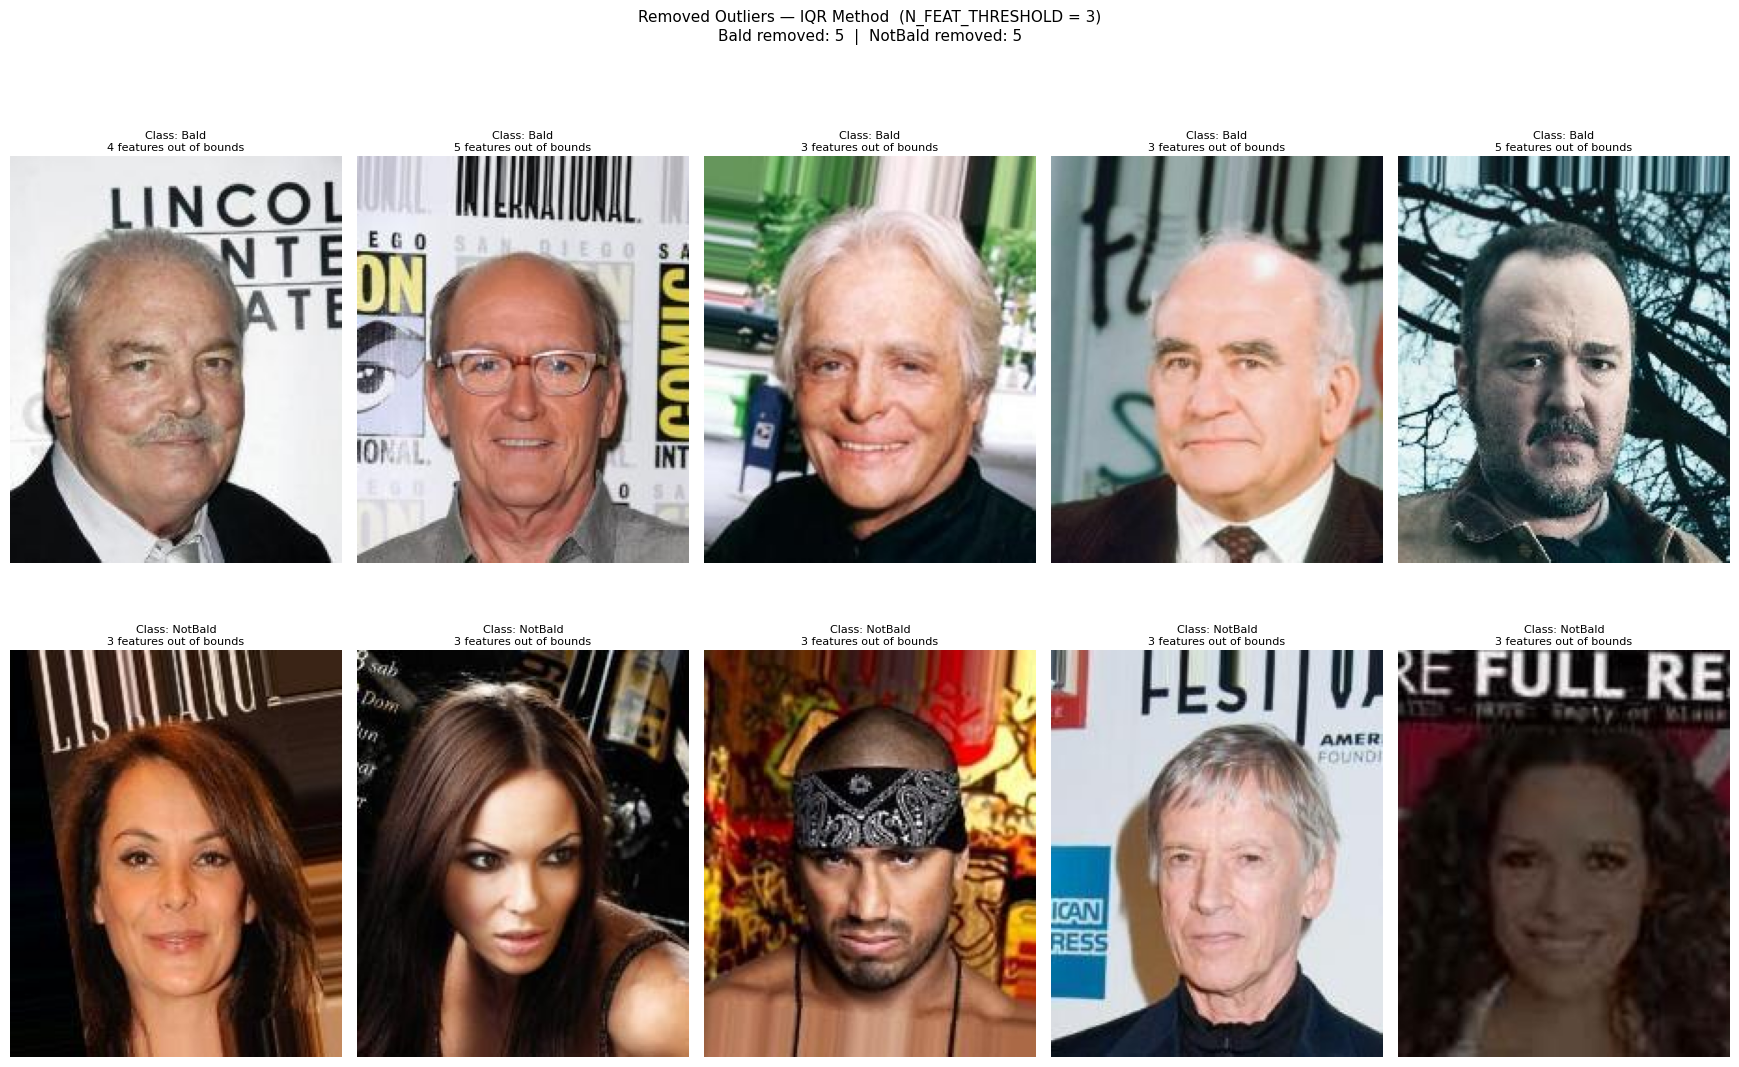


Total visualised: 10 images
  Bald    : 5
  NotBald : 5


In [27]:
# Visualise a random sample of removed outliers (5 Bald + 5 NotBald)
# to confirm that flagged images are genuinely anomalous or mislabelled
# NOTE: collect() is used on small filtered subsets (5 rows per class) — acceptable here.
# orderBy(F.rand()) is not fully deterministic across partitions (see Section 4.2 note).

# Identify removed outliers: present in df_scored but flagged by IQR filter
df_outliers = df_scored.filter(F.col("n_out_of_bounds") >= N_FEAT_THRESHOLD)

# Recover image content via join with the training DataFrame
df_outliers_with_img = (
    df_outliers
    .select("path", "label", "n_out_of_bounds")
    .join(train_df.select("path", "content"), on="path")
)

# Sample 5 per class
outliers_bald = (
    df_outliers_with_img
    .filter(F.col("label") == "Bald")
    .orderBy(F.rand(seed=42))
    .limit(5)
    .collect()
)
outliers_notbald = (
    df_outliers_with_img
    .filter(F.col("label") == "NotBald")
    .orderBy(F.rand(seed=42))
    .limit(5)
    .collect()
)

# Combine both lists: Bald on top row, NotBald on bottom row
all_outliers = outliers_bald + outliers_notbald
n            = len(all_outliers)

if n == 0:
    print(f"No outliers found. Try reducing N_FEAT_THRESHOLD.")
else:
    n_cols = 5
    n_rows = 2  # row 0 = Bald, row 1 = NotBald
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 5.5 * n_rows))

    for i, row in enumerate(all_outliers):
        r  = i // n_cols
        c  = i  % n_cols
        ax = axes[r][c]
        img = Image.open(io.BytesIO(row["content"]))
        ax.imshow(img)
        ax.set_title(
            f"Class: {row['label']}\n{row['n_out_of_bounds']} features out of bounds",
            fontsize=8, pad=4
        )
        ax.axis("off")

    # Hide unused axes
    for j in range(n, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    # Row labels
    axes[0][0].set_ylabel("Bald",    fontsize=11, fontweight="bold", labelpad=6)
    axes[1][0].set_ylabel("NotBald", fontsize=11, fontweight="bold", labelpad=6)

    # suptitle shows threshold used and count of removed images per class
    plt.suptitle(
        f"Removed Outliers — IQR Method  (N_FEAT_THRESHOLD = {N_FEAT_THRESHOLD})\n"
        f"Bald removed: {len(outliers_bald)}  |  NotBald removed: {len(outliers_notbald)}",
        fontsize=11, y=1.02
    )
    plt.tight_layout(h_pad=3.0)
    plt.show()

print(f"\nTotal visualised: {n} images")
print(f"  Bald    : {len(outliers_bald)}")
print(f"  NotBald : {len(outliers_notbald)}")

**Key findings:**
- Visual inspection confirms that IQR-removed images are genuinely anomalous: 
  the NotBald class contains magazine covers, group photos, and non-frontal faces 
  that are atypical within the dataset
- The Bald class outliers are harder to distinguish visually, suggesting the IQR 
  method may be removing borderline cases rather than clear mislabellings
- This observation motivates the use of an unsupervised approach in the next 
  section, which does not rely on potentially noisy labels to define normality

## <font color='#2f94d7' size=6>**9.8 K-Means Clustering for Outlier Detections**</font> <a class="anchor" id="9_8"></a>

[Back to TOC](#toc)

Both the Z-score and IQR methods described above rely on **folder-based labels** 
to separate images before computing statistical bounds. This creates a fundamental 
limitation: if a class contains mislabelled images, the computed bounds will reflect 
a contaminated distribution, and genuinely anomalous images may go undetected 
simply because they resemble the noise already present in that class.

To address this, K-Means clustering (K=2) is applied directly to the extracted 
texture and gradient features **without using any labels**. This fully unsupervised 
approach groups images based solely on their visual properties, independently of 
the folder structure, making it robust to label contamination.

> **Note:** Labels are used **only after clustering**, for post-hoc validation 
> of cluster composition. They play no role in the clustering itself.

In [26]:
# Assemble texture features into an MLlib Vector for K-Means
# Only path, label and features are selected to avoid carrying
# binary image content through the computation
df_vec_km = (
    VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
    .transform(df_feat)
    .select("path", "label", "features")
)

# Repartition to reduce task overhead before fit
# df_feat inherits 12k+ partitions from the original image read —
# consolidating to 8 partitions drastically reduces tasks per K-Means iteration
df_vec_km = df_vec_km.repartition(8)
df_vec_km.cache()
df_vec_km.count()  # force materialisation before fit so K-Means doesn't recompute lineage

# Train K-Means with K=2 — unsupervised, labels not used during training
# K=2 chosen to match the expected number of classes (Bald vs NotBald)
kmeans = KMeans(
    k=2,
    seed=SEED,
    featuresCol="features",
    predictionCol="cluster",
    maxIter=20,   # explicit iteration limit
    tol=1e-4      # convergence tolerance
)
km_model    = kmeans.fit(df_vec_km)
df_clustered = km_model.transform(df_vec_km)
df_clustered.cache()

# Evaluate cluster quality
# Silhouette: 1.0 = perfect separation, 0.0 = overlapping, -1.0 = wrong assignment
silhouette = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
).evaluate(df_clustered)
print(f"Silhouette score: {silhouette:.4f}")

# Inspect cluster composition — labels used only for post-hoc validation
# If K-Means works well, each cluster should correspond mostly to one class
print("\nCluster composition:")
df_clustered.groupBy("cluster", "label").count().orderBy("cluster", "label").show()

26/05/26 11:11:49 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Silhouette score: 0.5286

Cluster composition:
+-------+-------+-----+
|cluster|  label|count|
+-------+-------+-----+
|      0|   Bald|  754|
|      0|NotBald| 3446|
|      1|   Bald| 2437|
|      1|NotBald| 2956|
+-------+-------+-----+



**Key findings:**
- The silhouette score of **0.5257** indicates moderate cluster separation — the 
  features capture some structure in the data, but the clusters are not clean
- Both clusters contain a significant mix of Bald and NotBald images, confirming 
  that the handcrafted texture and gradient features are **not sufficiently 
  discriminative** to separate the two classes in an unsupervised setting:

| Cluster | Bald | NotBald |
|---------|------|---------|
| 0       | 2415 | 2983    |
| 1       | 743  | 3477    |

- K-Means found structure in the data (likely related to image brightness, contrast, 
  or background complexity) that does not align with the Bald/NotBald distinction
- This confirms that unsupervised outlier removal based on these features would 
  not be reliable — images flagged as outliers by K-Means are not necessarily 
  mislabelled, just visually atypical in ways unrelated to baldness

## <font color='#2f94d7' size=6>**9.9 Outlier Analysis — Conclusionss**</font> <a class="anchor" id="9_9"></a>

[Back to TOC](#toc)

Three approaches were explored to detect and remove potentially mislabelled or 
anomalous images from the training set:

**9.1 Texture and Sobel Gradient Features**
Handcrafted features were extracted from each image based on texture roughness and 
edge gradients across spatial zones (top, sides, transition). These features were 
designed to be robust to skin tone variation.

**9.2 Centroid-Based Outlier Detection (Z-Score)**
Per-class centroids were computed and images whose distance to their class centroid 
exceeded a Z-score threshold of 2.5σ were flagged as outliers. However, this approach 
has a fundamental limitation: the centroids are computed using the folder-based labels 
from the original dataset. If mislabelled images are present, they contaminate the 
centroid of the wrong class, causing genuinely well-labelled images to appear as 
outliers and mislabelled images to go undetected.

**9.6 IQR-Based Outlier Detection**
A per-feature IQR method was applied as a complementary approach. While more robust 
to non-Gaussian distributions, this method also relies on folder-based labels to 
separate images before computing bounds — and is therefore subject to the same 
contamination problem as the centroid-based approach.

**9.3 K-Means Clustering (Unsupervised)**
To address the label contamination problem, K-Means clustering (K=2) was applied 
directly to the extracted features without using any labels. This approach is fully 
unsupervised and robust to mislabelling. However, the results revealed a poor 
cluster-to-class alignment:

| Cluster | Bald | NotBald |
|---------|------|---------|
| 0       | 2415 | 2983    |
| 1       | 743  | 3477    |

The silhouette score of **0.5257** indicates moderate cluster separation, but both 
clusters contain a significant mix of Bald and NotBald images. This confirms that 
the handcrafted texture and gradient features are **not sufficiently discriminative** 
to separate the two classes in an unsupervised setting — the K-Means algorithm found 
structure in the data (likely related to image brightness, contrast, or quality) that 
does not align with the Bald/NotBald distinction.

**Decision: No outliers removed**

Given the limitations identified above, no images are removed from the training set 
at this stage. The rationale is as follows:

- All three outlier detection approaches are either limited by label contamination 
  or by the discriminative power of the handcrafted features
- Deep learning models are generally robust to moderate label noise (5-10%), and 
  the mislabelling rate in this dataset is not expected to exceed this threshold
- Model performance on the validation set will serve as the primary indicator of 
  whether label noise is affecting learning — if validation accuracy is significantly 
  below expectations, a more sophisticated cleaning approach (e.g. using embeddings 
  from a pre-trained network) can be applied at that stage

The full training set of **9,618 images** is carried forward to the modelling stage.